# **Data Preprocessing**

**Project:** Airbnb Pricing Analysis

**Team:** Jessie Dicker, Norma Arredondo

**Date:** March 22, 2026




## Table Contents
1. Data Load
2. Drop Rows with Missing TARGET
3. Simple Cleaning
4. Train-Test Split
5. Handle Missing Values
6. Handle Outliers
7. Key Finding Summary

## 1. Load Data

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns', None)

print("✓ Libraries loaded!")

✓ Libraries loaded!


In [2]:
# Load your data
df = pd.read_csv('../data/raw/AB_NYC_2019.csv')
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [3]:
# Data Shape
df.shape

(48895, 16)

In [4]:
# Data Frame information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

### Load Data: Questions

- How many rows and columns does your raw dataset have?

There are 48,895 rows and 16 columns in the raw dataset.

- Which columns are your target variable?

The only target variable in this project is 'price'.

- What issues from Notebook 01 will you address in this notebook?

In this notebook, we will address the value of the impossible values in price and availability. As well as handling missing values and outliers.

## 2. Drop Rows with Missing TARGET

In [5]:
target_col = 'price'
missing_target = df[target_col].isnull().sum()


print(f"\n Mising values in target '{target_col}' : {missing_target}")
print(f"Percentage:  {missing_target/len(df)*100:.2f}%")


 Mising values in target 'price' : 0
Percentage:  0.00%


In [6]:
# DROP rows with missing target
df_clean = df.dropna(subset=['price'])

In [7]:
# Verify no missing targets remain

df_clean[target_col].isnull().sum()

np.int64(0)

In [8]:
# Check missing value in df_clean in features

df_clean.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [9]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

### Drop Rows with Missing TARGET: Questions
- How many rows had a missing target value?

There are 0 rows with missing values in our target variable, price.
  
- What percentage of the dataset does that represent?

It represent 0.00% of the dataset.

- How many rows remain after dropping?

There are still 48,895 rows remaining after dropping.

## 3. Simple Cleaning

In [10]:
# Check for duplicates
duplicates = df_clean.duplicated().sum()
print(f'\n Duplicate rows found: {duplicates}')


 Duplicate rows found: 0


In [11]:
# Remove duplicates
if duplicates>0:
    df_clean = df_clean.drop_duplicates()
    print(f'removed {duplicates} duplicated rows')
else:
    print('No duplicates removed')

No duplicates removed


In [12]:
# check impossible values
positive_col = ['price', 'minimum_nights', 'number_of_reviews', 
                'reviews_per_month', 'calculated_host_listings_count', 
                'availability_365']
for col in positive_col:
    neg_count = (df_clean[col]<0).sum()
    if neg_count:
        print(f'{col}: has negative values')

        ## remove negative values
        df_clean = df_clean[df_clean[col]>=0]

        print(f'removed {neg_count} rows with negative {col}')

In [13]:
# Remove price = 0 
zero_price = (df_clean['price'] == 0).sum()
print(f'\nRows with Price = $0: {zero_price}')

df_clean = df_clean[df_clean['price'] > 0]
print(f'Removed {zero_price} rows with price = $0')

# Remove availability_365 more than 365
avail_365 = (df_clean['availability_365'] > 365).sum()
print(f'\nRows with more than 365: {avail_365}')

if avail_365:
    df_clean = df_clean[df_clean['availability_365'] <= 365]
    print(f'Removed {avail_365} rows with availability > 365')


Rows with Price = $0: 11
Removed 11 rows with price = $0

Rows with more than 365: 0


In [14]:
# Drop data leakage
leakage_cols = ['id', 'name', 'host_id', 'host_name', 'last_review']

df_clean = df_clean.drop(columns=leakage_cols)
print(f'Dropped columns: {leakage_cols}')
print(f'Remaining columns: {df_clean.columns.tolist()}')

Dropped columns: ['id', 'name', 'host_id', 'host_name', 'last_review']
Remaining columns: ['neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']


In [15]:
# Verify no more impossible values

positive_col = ['price', 'minimum_nights', 'number_of_reviews', 
                'reviews_per_month', 'calculated_host_listings_count', 
                'availability_365']

issue_found = False
for col in positive_col:
    neg_count = (df_clean[col]<0).sum()
    if neg_count:
        print(f'{col}: has negative values')
        issue_found = True

if not issue_found:
    print('No impossible values remaining')

No impossible values remaining


In [16]:
print(f"\nDataset shape originally: {df.shape}")
print(f"\nDataset shape after all pre-split cleaning: {df_clean.shape}")


Dataset shape originally: (48895, 16)

Dataset shape after all pre-split cleaning: (48884, 11)


In [17]:
# Identify the 99th percentile of target and drop to avoid outliers

p99 = df_clean['price'].quantile(0.99)
df_clean = df_clean[df_clean['price'] <= p99]

In [18]:
df_clean['price'].describe()

count    48410.000000
mean       137.575170
std        103.780081
min         10.000000
25%         69.000000
50%        105.000000
75%        175.000000
max        799.000000
Name: price, dtype: float64

### Cleaning Notes
- After duplicates removal, 48,895 rows remain because there are no duplicates. 
- Impossible Values were removed, including price equal to and less than 0, because it is not a realistic listing, and rows with more than 365 in availability_365, because it should exceed 365 days.
- Data leakage columns dropped:

  id - A unique identifier, and it's not a predictive value

  name - Not a structured feature

  host_id - It is an arbitrary numerical identifier

  host_name - name is not a predictive value

  last_review - this column would leak temporal information
- After removing duplicates, impossible values, and data leakage, there are 48,884 rows and 11 columns left.
- The target variable `price` was capped and outliers were removed to ensure the data was not skewed. 

## 4. Train-Test Split

In [19]:
# Separate the features and the target variable

X = df_clean.drop('price', axis=1)
y = df_clean['price']

In [20]:
# Visualize data
X.head()

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,1,9,0.21,6,365
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,1,45,0.38,2,355
2,Manhattan,Harlem,40.80902,-73.94190,Private room,3,0,NaN,1,365
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,1,270,4.64,1,194
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,10,9,0.10,1,0


In [21]:
# Visualize data
y.head()

0    149
1    225
2    150
3     89
4     80
Name: price, dtype: int64

In [22]:
# Visualize data
print(f"\nFeatures (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")


Features (X) shape: (48410, 10)
Target (y) shape: (48410,)


In [23]:
# Split the data

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=4950)

In [24]:
#Visualize the data split

print(f'Training:{X_train.shape[0]:,} samples')
print(f'Test:{X_test.shape[0]:,} samples')

Training:38,728 samples
Test:9,682 samples


In [25]:
X_train.head()

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
45254,Brooklyn,Bushwick,40.69240,-73.91448,Private room,31,0,NaN,2,365
29175,Manhattan,Harlem,40.81455,-73.95122,Private room,3,1,0.07,1,0
47522,Queens,Astoria,40.76019,-73.92489,Entire home/apt,3,0,NaN,1,109
594,Manhattan,Midtown,40.74267,-73.98569,Entire home/apt,4,3,0.03,1,0
45496,Manhattan,Lower East Side,40.71482,-73.98911,Entire home/apt,4,2,2.00,2,0


In [26]:
X_test.head()

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
36013,Bronx,Soundview,40.82890,-73.86219,Entire home/apt,1,54,5.61,1,326
13611,Brooklyn,Carroll Gardens,40.67875,-73.99599,Entire home/apt,3,9,0.21,1,0
45500,Manhattan,East Village,40.72600,-73.97861,Private room,5,5,5.00,1,47
7322,Manhattan,East Village,40.73117,-73.98335,Entire home/apt,30,10,0.20,39,311
44457,Manhattan,Chinatown,40.71333,-73.99419,Entire home/apt,2,5,2.42,1,231


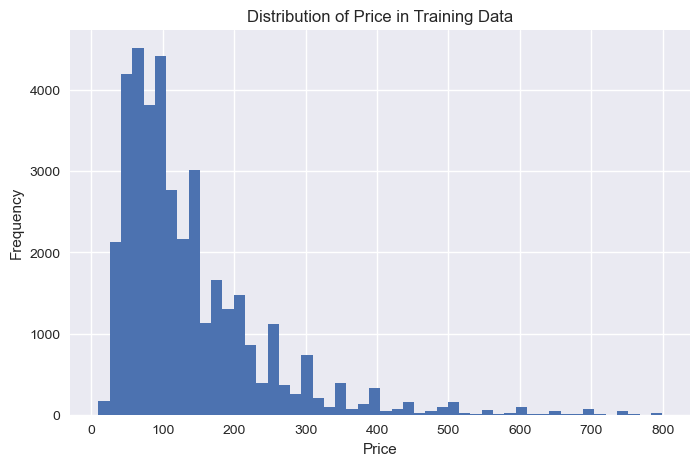

In [27]:
# Visualize the target variable

plt.figure(figsize=(8,5))
plt.hist(y_train, bins=50)
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Distribution of Price in Training Data')
plt.show()

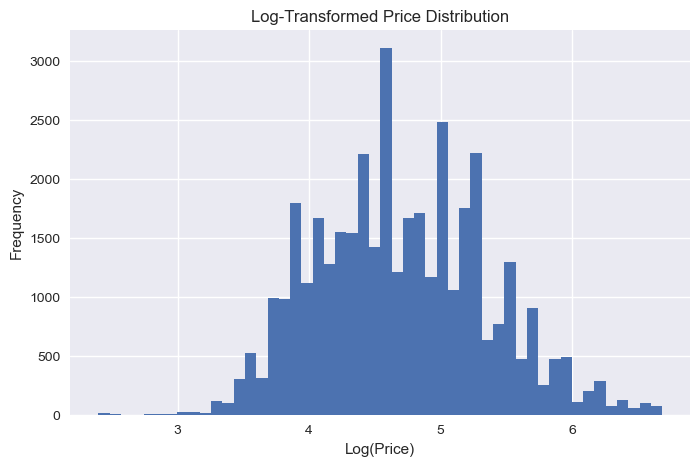

In [28]:
# See if a log transformation would be beneficial for regression
plt.figure(figsize=(8,5))
plt.hist(np.log1p(y_train), bins=50)
plt.xlabel('Log(Price)')
plt.ylabel('Frequency')
plt.title('Log-Transformed Price Distribution')
plt.show()

In [68]:
# y_train = np.expm1(y_train)
# y_test = np.expm1(y_test)

### Train/Test Split Notes
- The original dataset was split into the predictor variables and the target variable
- After the 80%/20% train/test split, the training data consisted of 39,107 observations and the test consisted of 9,777 observations.
- The target variable is skewed right, and based on visualizations may need to be log-transformed for modeling 

## 5. Handle Missing Values

In [29]:
# Visualize the training data
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 38728 entries, 45254 to 6083
Data columns (total 10 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neighbourhood_group             38728 non-null  object 
 1   neighbourhood                   38728 non-null  object 
 2   latitude                        38728 non-null  float64
 3   longitude                       38728 non-null  float64
 4   room_type                       38728 non-null  object 
 5   minimum_nights                  38728 non-null  int64  
 6   number_of_reviews               38728 non-null  int64  
 7   reviews_per_month               30860 non-null  float64
 8   calculated_host_listings_count  38728 non-null  int64  
 9   availability_365                38728 non-null  int64  
dtypes: float64(3), int64(4), object(3)
memory usage: 3.3+ MB


In [30]:
# Visualize the missing data
X_train.isnull().sum()

neighbourhood_group                  0
neighbourhood                        0
latitude                             0
longitude                            0
room_type                            0
minimum_nights                       0
number_of_reviews                    0
reviews_per_month                 7868
calculated_host_listings_count       0
availability_365                     0
dtype: int64

- The only feature in the training data with missing values that need to be filled is the reviews_per_month feature

In [31]:
# See how much of each feature is missing data
print(f'Missing %: {X_train.isnull().sum()/len(X_train)*100}')

Missing %: neighbourhood_group                0.00000
neighbourhood                      0.00000
latitude                           0.00000
longitude                          0.00000
room_type                          0.00000
minimum_nights                     0.00000
number_of_reviews                  0.00000
reviews_per_month                 20.31605
calculated_host_listings_count     0.00000
availability_365                   0.00000
dtype: float64


In [32]:
# Visualize the test data
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9682 entries, 36013 to 22122
Data columns (total 10 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neighbourhood_group             9682 non-null   object 
 1   neighbourhood                   9682 non-null   object 
 2   latitude                        9682 non-null   float64
 3   longitude                       9682 non-null   float64
 4   room_type                       9682 non-null   object 
 5   minimum_nights                  9682 non-null   int64  
 6   number_of_reviews               9682 non-null   int64  
 7   reviews_per_month               7723 non-null   float64
 8   calculated_host_listings_count  9682 non-null   int64  
 9   availability_365                9682 non-null   int64  
dtypes: float64(3), int64(4), object(3)
memory usage: 832.0+ KB


In [33]:
X_test.isnull().sum()

neighbourhood_group                  0
neighbourhood                        0
latitude                             0
longitude                            0
room_type                            0
minimum_nights                       0
number_of_reviews                    0
reviews_per_month                 1959
calculated_host_listings_count       0
availability_365                     0
dtype: int64

- The reviews_per_month feature is the only feature that has null values in the test data

In [34]:
# Visualize the summary statistics of the feature that needs to be filled
X_train['reviews_per_month'].describe()

count    30860.000000
mean         1.374213
std          1.655288
min          0.010000
25%          0.190000
50%          0.720000
75%          2.020000
max         20.940000
Name: reviews_per_month, dtype: float64

In [35]:
# See if the number of the reviews matches the reviews per month (roughly)
X_train['number_of_reviews'].describe()

count    38728.000000
mean        23.381016
std         44.665386
min          0.000000
25%          1.000000
50%          5.000000
75%         24.000000
max        629.000000
Name: number_of_reviews, dtype: float64

In [36]:
# For rows where number of reviews is zero, set reviews per month to zero too
X_train.loc[X_train['number_of_reviews'] == 0, 'reviews_per_month'] = 0

In [37]:
# See how many missing values are left in the column
X_train['reviews_per_month'].isna().sum()

np.int64(0)

In [38]:
# See how the variable statistics has changed 
X_train['reviews_per_month'].describe()

count    38728.000000
mean         1.095027
std          1.577667
min          0.000000
25%          0.040000
50%          0.380000
75%          1.600000
max         20.940000
Name: reviews_per_month, dtype: float64

In [39]:
# See the summary statistics of the feature with missing values in the test data
X_test['reviews_per_month'].describe()

count    7723.000000
mean        1.383377
std         1.788830
min         0.010000
25%         0.190000
50%         0.710000
75%         2.030000
max        58.500000
Name: reviews_per_month, dtype: float64

In [40]:
X_test['number_of_reviews'].describe()

count    9682.000000
mean       23.539248
std        44.840821
min         0.000000
25%         1.000000
50%         5.000000
75%        23.000000
max       607.000000
Name: number_of_reviews, dtype: float64

In [41]:
# For rows where number of reviews is zero, set reviews per month to zero too
X_test.loc[X_test['number_of_reviews'] == 0, 'reviews_per_month'] = 0

In [42]:
# Visualize the missing values after imputing 
X_test['reviews_per_month'].isna().sum()

np.int64(0)

In [43]:
# See how the variable statistics has changed 
X_test['reviews_per_month'].describe()

count    9682.000000
mean        1.103472
std         1.691535
min         0.000000
25%         0.040000
50%         0.380000
75%         1.610000
max        58.500000
Name: reviews_per_month, dtype: float64

| Column                | % Missing | Strategy        | Reasoning |
|----------------------|----------|-----------------|-----------|
| reviews_per_month    | ~20.5%   | Impute with 0   | Missing values correspond to listings with no reviews so we will impute with zero |

### Missing Values Notes
- Before imputing, the reviews_per_month was missing 8,021 values in the training data and 2,030 in the test data
- Both train and test data were imputed with the matching values from the number_of_reviews column if the number of reviews is zero
- After this, the data is not missing any more values

## 6. Handle Outliers

In [44]:
# Find numerical columns 

numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f'Numerical columns ({len(numerical_cols)}):')
numerical_cols

Numerical columns (7):


['latitude',
 'longitude',
 'minimum_nights',
 'number_of_reviews',
 'reviews_per_month',
 'calculated_host_listings_count',
 'availability_365']

In [45]:
# See what percentage of numerical features are outliers

for col in numerical_cols:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5*IQR
    upper_bound = Q3 + 1.5*IQR
    n_outliers = ((X_train[col]<lower_bound)|(X_train[col]>upper_bound)).sum()
    percent = (n_outliers/len(X_train)) *100
    print(f'{col}: {n_outliers} outliers ({percent:.2f}%)')

latitude: 321 outliers (0.83%)
longitude: 2256 outliers (5.83%)
minimum_nights: 5263 outliers (13.59%)
number_of_reviews: 4788 outliers (12.36%)
reviews_per_month: 2569 outliers (6.63%)
calculated_host_listings_count: 5593 outliers (14.44%)
availability_365: 0 outliers (0.00%)


- With domain knowledge in mind, the only features that should be capped are 'minimum_nights' and 'calculated_host_listings_count'
- The other high values are meaningful and should not be capped

In [46]:
# Cap minimum_nights and calculated_host_listings_count

columns_to_cap = ['minimum_nights', 'calculated_host_listings_count']

def cap_outlier(train_data, test_data, columns):
    train_capped = train_data.copy()
    test_capped = test_data.copy() 
    for col in columns:
        Q1 = train_capped[col].quantile(0.25)
        Q3 = train_capped[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5*IQR
        upper_bound = Q3 + 1.5*IQR

        train_capped[col] = train_capped[col].clip(lower=lower_bound,upper=upper_bound)
        test_capped[col] = test_capped[col].clip(lower=lower_bound,upper=upper_bound)
        
    return train_capped, test_capped


columns_to_cap = ['minimum_nights', 'calculated_host_listings_count']

X_train_final,X_test_final=  cap_outlier(X_train,X_test,columns_to_cap)


print(f'shape of X_train {X_train_final.shape:}')
print(f'shape of X_test {X_test_final.shape:}')

shape of X_train (38728, 10)
shape of X_test (9682, 10)


| Column                           | % Outliers | Decision | Reasoning |
|----------------------------------|-----------|----------|-----------|
| latitude                         | 0.86%     | Keep     | Values represent geographic locations and should not be modified. |
| longitude                        | 5.79%     | Keep     | Values represent geographic locations and should not be modified. |
| minimum_nights                   | 13.45%    | Cap      | Extremely high minimum night requirements are unlikely and can distort model training |
| number_of_reviews                | 12.75%    | Keep     | High review counts indicate popular listings and contain meaningful information for modeling.|
| reviews_per_month                | 6.87%     | Keep     | High review counts indicate popular listings and contain meaningful information for modeling. |
| calculated_host_listings_count   | 14.45%    | Cap      | Hosts with very large portfolios are rare so they should be capped to avoid model bias. |
| availability_365                 | 0.00%     | Keep     | No outliers detected. |

### Handling Outliers Notes
- The only columns with outliers that should be capped were 'minimum_nights' and 'calculated_host_listings_count' as the other features were not good fits for Windsorization. Their high values could have a predictive impact
    - Latitude and longitude are both positional data, so we should not change their values
    - Number of reviews and monthly reviews could be indicitive of active or inactive listings
- Once the data was capped, the training data had 39,107 rows and the test data had 9,777 rows

In [47]:
# Data validation
## 1. Check for missing values
print("\n1. Missing Values:")
print(f"   X_train: {X_train_final.isnull().sum().sum()} missing")
print(f"   X_test:  {X_test_final.isnull().sum().sum()} missing")
print(f"   y_train: {y_train.isnull().sum()} missing")
print(f"   y_test:  {y_test.isnull().sum()} missing")

## 2. Check for infinite values (numeric columns only)
print("\n2. Infinite Values:")
num_cols = X_train_final.select_dtypes(include=['int64', 'float64']).columns
print(f"   X_train: {np.isinf(X_train_final[num_cols]).sum().sum()} infinite")
print(f"   X_test:  {np.isinf(X_test_final[num_cols]).sum().sum()} infinite")

## 3. Check Target Distribution
print("\n3. Target Distribution Check:")
print(f"   y_train mean:   {y_train.mean():.2f}")
print(f"   y_test mean:    {y_test.mean():.2f}")
print(f"   y_train median: {y_train.median():.2f}")
print(f"   y_test median:  {y_test.median():.2f}")
print(f"   y_train min/max: {y_train.min():.2f} / {y_train.max():.2f}")
print(f"   y_test min/max:  {y_test.min():.2f} / {y_test.max():.2f}")

## 4. Final shapes
print("\n4. Final Shapes:")
print(f"   X_train: {X_train_final.shape}")
print(f"   X_test:  {X_test_final.shape}")
print(f"   y_train: {y_train.shape}")
print(f"   y_test:  {y_test.shape}")


1. Missing Values:
   X_train: 0 missing
   X_test:  0 missing
   y_train: 0 missing
   y_test:  0 missing

2. Infinite Values:
   X_train: 0 infinite
   X_test:  0 infinite

3. Target Distribution Check:
   y_train mean:   137.59
   y_test mean:    137.52
   y_train median: 105.00
   y_test median:  103.00
   y_train min/max: 10.00 / 799.00
   y_test min/max:  10.00 / 799.00

4. Final Shapes:
   X_train: (38728, 10)
   X_test:  (9682, 10)
   y_train: (38728,)
   y_test:  (9682,)


In [48]:
# Save the processed data 
import os
import pickle

# Create directory
os.makedirs('../data/processed', exist_ok=True)

# Save processed data
X_train_final.to_csv('../data/processed/X_train.csv', index=False)
X_test_final.to_csv('../data/processed/X_test.csv', index=False)
y_train.to_csv('../data/processed/y_train.csv', index=False)
y_test.to_csv('../data/processed/y_test.csv', index=False)

## Key Findings Summary

### Before Split:
- Original dataset contained 48,895 observations 
- All infinite values were handled
- There were no duplicates in the dataset
- Columns causing possible leakage were dropped

### During Split:
- The target variable 'price' and the predictors were separated
- Data was split into roughly 80% training and 20% test data

### After Split:
- Imputed the missing values in reviews per month with zero if the number of reviews was zero
- Handled outliers in 'minimum_nights' and 'calculated_host_listings_count' using Winsorization (capping) method
- Did not cap the other features as they could hold important predictive power or were incompatible with capping (positional data)
- The final training data consisted of 39,107 rows and the test of 9,777 rows
    - No data was lost in the preprocessing